# Exploratory Data Analysis — Carbon Intensity, Renewable Fraction & Carbon-Free Energy
## Thesis: Carbon-Intelligent Workload Scheduling for AI Data Centers
**Author**: Yaxin (Isabel) Wu | **Supervisor**: Prof. Bissan Ghaddar | IE University, 2026

---

### Overview
This notebook performs EDA on hourly Carbon Intensity (CI), Renewable Fraction (RF), and Carbon-Free Energy fraction (CFE) data retrieved from the ElectricityMaps API for five target grid regions: **PJM, NYISO, Finland, Belgium, and Singapore**, covering **2024–2025** (17,544 hours per region).

- **CI** (gCO₂eq/kWh): direct carbon cost of electricity consumed — the primary LP objective signal.
- **RF**: share of wind + solar + hydro + geothermal + biomass in total generation (excludes nuclear).
- **CFE fraction**: share of all carbon-free sources = RF + nuclear. This is the scheduling signal used by Riepin et al. (2024) in the closest prior LP.
- **Nuclear fraction** = CFE − RF. Varies strongly by region (near-zero in Singapore/PJM, substantial in Belgium/Finland).

The analysis addresses two modeling questions: (1) does CFE carry scheduling-relevant information beyond CI alone? (2) is CFE a stronger signal than RF, motivating its use in the LP objective?

> **Note on CFE data**: CFE requires nuclear breakdown from ElectricityMaps `powerConsumptionBreakdown`. Run `src/fetch_cfe.py` to populate this. Sections 9–10 degrade gracefully if CFE is not yet available.

The analysis proceeds as follows:
1. Data loading and inspection
2. Data quality checks and cleaning
3. Descriptive statistics (CI, RF, CFE, nuclear)
4. CI variability (CV) by region
5. CI distributions, time series, diurnal and seasonal patterns
6. RF vs CFE analysis — nuclear contribution by region
7. CI–CFE relationship — correlation, OLS regression, functional form
8. Key findings and modeling implications

---
## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

# Region metadata
ZONES = {
    "US-MIDA-PJM": {"label": "PJM",       "color": "#e05c5c"},
    "US-NY-NYIS":  {"label": "NYISO",     "color": "#e08c3a"},
    "FI":          {"label": "Finland",   "color": "#5ca85c"},
    "BE":          {"label": "Belgium",   "color": "#5c7ae0"},
    "SG":          {"label": "Singapore", "color": "#9b59b6"},
}

print("Imports OK")

Imports OK


---
## 2. Data Loading

We load the pre-fetched `.parquet` files for each zone and merge CI and RF into a single DataFrame per region. The `datetime` column is parsed to UTC-aware timestamps and used as the index throughout the analysis.

In [2]:
import os

data = {}
for zone, meta in ZONES.items():
    ci = pd.read_parquet(f"../data/raw/{zone}_ci.parquet")
    rf = pd.read_parquet(f"../data/raw/{zone}_rf.parquet")

    df = pd.merge(ci, rf, on="datetime", how="inner")
    df["datetime"] = pd.to_datetime(df["datetime"], utc=True)
    df = df.set_index("datetime").sort_index()

    if "cfe_fraction" in df.columns:
        df = df.rename(columns={
            "carbon_intensity":   "ci",
            "renewable_fraction": "rf",
            "nuclear_fraction":   "nuclear",
            "cfe_fraction":       "cfe",
        })
    else:
        df = df.rename(columns={"carbon_intensity": "ci", "renewable_fraction": "rf"})
        df["nuclear"] = np.nan
        df["cfe"]     = np.nan

    df["zone"] = meta["label"]
    data[zone] = df

HAS_CFE = all(df["cfe"].notna().any() for df in data.values())
print(f"CFE data available: {HAS_CFE}")
if not HAS_CFE:
    print("  → Run src/fetch_cfe.py to add nuclear + CFE columns to the parquet files.")
print()
for zone, df in data.items():
    print(f"{ZONES[zone]['label']:10}  rows={len(df):,}  CI_null={df['ci'].isna().sum()}"
          f"  RF_null={df['rf'].isna().sum()}"
          f"  CFE_null={df['cfe'].isna().sum()}"
          f"  range={df.index.min().date()} → {df.index.max().date()}")

CFE data available: True

PJM         rows=17,544  CI_null=0  RF_null=194  CFE_null=194  range=2024-01-01 → 2025-12-31
NYISO       rows=17,544  CI_null=0  RF_null=1  CFE_null=1  range=2024-01-01 → 2025-12-31
Finland     rows=17,544  CI_null=0  RF_null=0  CFE_null=0  range=2024-01-01 → 2025-12-31
Belgium     rows=17,544  CI_null=0  RF_null=0  CFE_null=0  range=2024-01-01 → 2025-12-31
Singapore   rows=17,544  CI_null=0  RF_null=0  CFE_null=0  range=2024-01-01 → 2025-12-31


In [4]:
data

{'US-MIDA-PJM':                             ci        rf   nuclear       cfe zone
 datetime                                                         
 2024-01-01 00:00:00+00:00  456  0.105658  0.286833  0.392491  PJM
 2024-01-01 01:00:00+00:00  453  0.095854  0.297190  0.393044  PJM
 2024-01-01 02:00:00+00:00  456  0.076067  0.307233  0.383300  PJM
 2024-01-01 03:00:00+00:00  452  0.070041  0.315552  0.385593  PJM
 2024-01-01 04:00:00+00:00  453  0.065652  0.317233  0.382885  PJM
 ...                        ...       ...       ...       ...  ...
 2025-12-31 19:00:00+00:00  504  0.097494  0.323768  0.421262  PJM
 2025-12-31 20:00:00+00:00  504  0.093584  0.325189  0.418773  PJM
 2025-12-31 21:00:00+00:00  509  0.091237  0.321867  0.413104  PJM
 2025-12-31 22:00:00+00:00  510  0.097113  0.311521  0.408633  PJM
 2025-12-31 23:00:00+00:00  512  0.094031  0.314096  0.408126  PJM
 
 [17544 rows x 5 columns],
 'US-NY-NYIS':                             ci        rf   nuclear       cfe   zone
 d

---
## 3. Data Quality Checks & Cleaning

Before any analysis, we systematically verify data integrity across four dimensions:

1. **Explicit missing values** — NaN in CI or RF columns
2. **Duplicate timestamps** — same datetime appearing more than once
3. **Time series continuity** — gaps in the expected hourly sequence (implicit missing hours)
4. **Physical plausibility** — values outside valid ranges (CI < 0 or > 1,000 gCO₂/kWh; RF outside [0, 1])

Any issues found here would require imputation or removal before the data enters the optimization model. Results are documented regardless of outcome — a clean dataset still needs proof of cleanliness.

In [ ]:
issues = []

for zone, df in data.items():
    label = ZONES[zone]["label"]

    # 1. Explicit nulls
    ci_null = df["ci"].isna().sum()
    rf_null = df["rf"].isna().sum()

    # 2. Duplicate timestamps
    dupes = df.index.duplicated().sum()

    # 3. Time series continuity — expected hourly index vs actual
    expected = pd.date_range(start=df.index.min(), end=df.index.max(), freq="h", tz="UTC")
    missing_hours = expected.difference(df.index)

    # 4. Physical plausibility
    ci_negative  = (df["ci"] < 0).sum()
    ci_too_high  = (df["ci"] > 1000).sum()
    rf_below_zero = (df["rf"] < 0).sum()
    rf_above_one  = (df["rf"] > 1).sum()

    issues.append({
        "Region":          label,
        "CI nulls":        ci_null,
        "RF nulls":        rf_null,
        "Duplicate ts":    dupes,
        "Missing hours":   len(missing_hours),
        "CI < 0":          ci_negative,
        "CI > 1000":       ci_too_high,
        "RF < 0":          rf_below_zero,
        "RF > 1":          rf_above_one,
    })

qc = pd.DataFrame(issues).set_index("Region")
print("=== Data Quality Report ===")
print(qc.to_string())

total_issues = qc.drop(columns=[]).values.sum()
print(f"\nTotal issues found: {total_issues}")
if total_issues == 0:
    print("✓ All checks passed — dataset is clean and ready for analysis.")

=== Data Quality Report ===
           CI nulls  RF nulls  Duplicate ts  Missing hours  CI < 0  CI > 1000  RF < 0  RF > 1
Region                                                                                       
PJM               0       194             0              0       0          0       0       0
NYISO             0         1             0              0       0          0       0       0
Finland           0         0             0              0       0          0       0       0
Belgium           0         0             0              0       0          0       0       0
Singapore         0         0             0              0       0          0       0       0

Total issues found: 195


In [ ]:
# Cleaning actions — applied if any issues are found
# If all checks passed above, this cell confirms no action was needed.

for zone, df in data.items():
    label = ZONES[zone]["label"]
    original_len = len(df)

    # Remove duplicate timestamps (keep first)
    df = df[~df.index.duplicated(keep="first")]

    # Reindex to full hourly range and forward-fill gaps ≤ 2 hours
    # (short gaps from API delays are acceptable; longer gaps would require investigation)
    full_idx = pd.date_range(start=df.index.min(), end=df.index.max(), freq="h", tz="UTC")
    df = df.reindex(full_idx)
    gap_count = df["ci"].isna().sum()
    if gap_count > 0:
        df = df.fillna(method="ffill", limit=2)
        remaining = df["ci"].isna().sum()
        print(f"{label}: filled {gap_count} gap(s) via forward-fill; {remaining} remaining NaN(s)")
    
    # Clip physically implausible values
    df["ci"] = df["ci"].clip(lower=0, upper=1000)
    df["rf"] = df["rf"].clip(lower=0, upper=1)

    data[zone] = df
    if len(df) != original_len or gap_count > 0:
        print(f"{label}: rows {original_len} → {len(df)}")

print("Cleaning complete. Final row counts:")
for zone, df in data.items():
    print(f"  {ZONES[zone]['label']:10}  {len(df):,} rows")

Cleaning complete. Final row counts:
  PJM         17,544 rows
  NYISO       17,544 rows
  Finland     17,544 rows
  Belgium     17,544 rows
  Singapore   17,544 rows


---
## 3. Descriptive Statistics

We compute per-region summary statistics for CI (gCO₂eq/kWh) and RF (%). These numbers directly inform the optimization model: a high CI mean signals a carbon-intensive grid; a high CI std signals strong temporal shifting potential.

In [ ]:
rows = []
for zone, df in data.items():
    row = {
        "Region":      ZONES[zone]["label"],
        "CI mean":     round(df["ci"].mean(), 1),
        "CI std":      round(df["ci"].std(), 1),
        "CI min":      int(df["ci"].min()),
        "CI max":      int(df["ci"].max()),
        "CI p25":      int(df["ci"].quantile(0.25)),
        "CI p75":      int(df["ci"].quantile(0.75)),
        "RF mean %":   round(df["rf"].mean() * 100, 1),
        "RF std %":    round(df["rf"].std() * 100, 1),
    }
    if HAS_CFE:
        row["Nuclear %"] = round(df["nuclear"].mean() * 100, 1)
        row["CFE %"]     = round(df["cfe"].mean() * 100, 1)
    rows.append(row)

stats = pd.DataFrame(rows).set_index("Region")
print(stats.to_string())
if HAS_CFE:
    print("\nNuclear % = CFE % − RF % (carbon-free but not renewable)")
else:
    print("\nNuclear and CFE columns not yet available — run src/fetch_cfe.py")

           CI mean  CI std  CI min  CI max  CI p25  CI p75  RF mean %  RF std %  Nuclear %  CFE %
Region                                                                                           
PJM          472.2    52.1     313     627     435     508        7.7       3.7       34.3   42.0
NYISO        353.7    44.2     215     499     325     383       25.2       5.6       25.8   51.1
Finland       82.7    34.7      34     285      57     100       58.6       6.7       35.4   94.0
Belgium      191.2    76.1      69     433     132     241       38.3      16.7       37.8   76.1
Singapore    533.2    59.8     391     584     511     578        2.7       3.9        0.0    2.7

Nuclear % = CFE % − RF % (carbon-free but not renewable)


---
## 4. CI Variability (CV) — Post-hoc Regional Diagnostic

**CV (Coefficient of Variation)** = σ(CI) / μ(CI) is computed from the full 2024–2025 historical series after data collection. It is not an input to the LP — incorporating a historical aggregate statistic into the objective would compromise the model's deterministic structure, since CV is only knowable after observing the entire time series.

Instead, CV is used as a post-hoc diagnostic: after backtesting, it explains why carbon savings vary across regions. Regions with high CI fluctuation (high CV) offer more room for temporal shifting, while regions with stable CI (low CV, e.g. Singapore) yield limited benefit regardless of the scheduling policy.

               CV Scheduling opportunity
Finland    0.4198                Highest
Belgium    0.3980                   High
NYISO      0.1250                 Medium
Singapore  0.1121                 Medium
PJM        0.1104                 Lowest


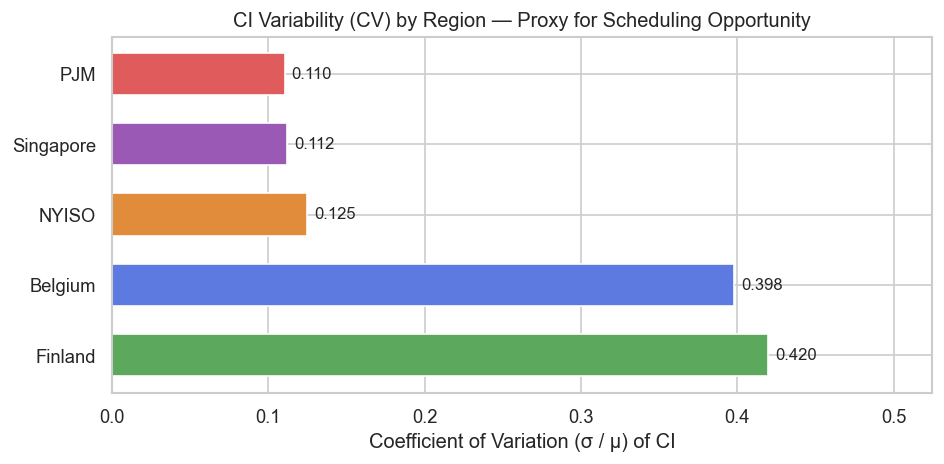

In [ ]:
cv_data = {ZONES[z]["label"]: round(data[z]["ci"].std() / data[z]["ci"].mean(), 4) for z in ZONES}
cv_df = pd.Series(cv_data, name="CV").sort_values(ascending=False).to_frame()
cv_df["Scheduling opportunity"] = ["Highest", "High", "Medium", "Medium", "Lowest"]
print(cv_df)

fig, ax = plt.subplots(figsize=(8, 4))
colors = [ZONES[z]["color"] for z in sorted(ZONES, key=lambda z: -data[z]["ci"].std()/data[z]["ci"].mean())]
bars = ax.barh(cv_df.index, cv_df["CV"], color=colors, edgecolor="white", height=0.6)
ax.set_xlabel("Coefficient of Variation (σ / μ) of CI")
ax.set_title("CI Variability (CV) by Region — Proxy for Scheduling Opportunity")
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=10)
ax.set_xlim(0, cv_df["CV"].max() * 1.25)
plt.tight_layout()
plt.savefig("../data/figures/eda_cv.png", bbox_inches="tight")
plt.show()

---
## 5. CI Distribution by Region

Boxplots and violin plots reveal the full distribution shape of CI per region. Wide IQR indicates high intra-region variability (PJM, NYISO). Finland shows a right-skewed distribution driven by seasonal nuclear + hydro variation. Singapore's narrow distribution confirms minimal temporal shifting opportunity.

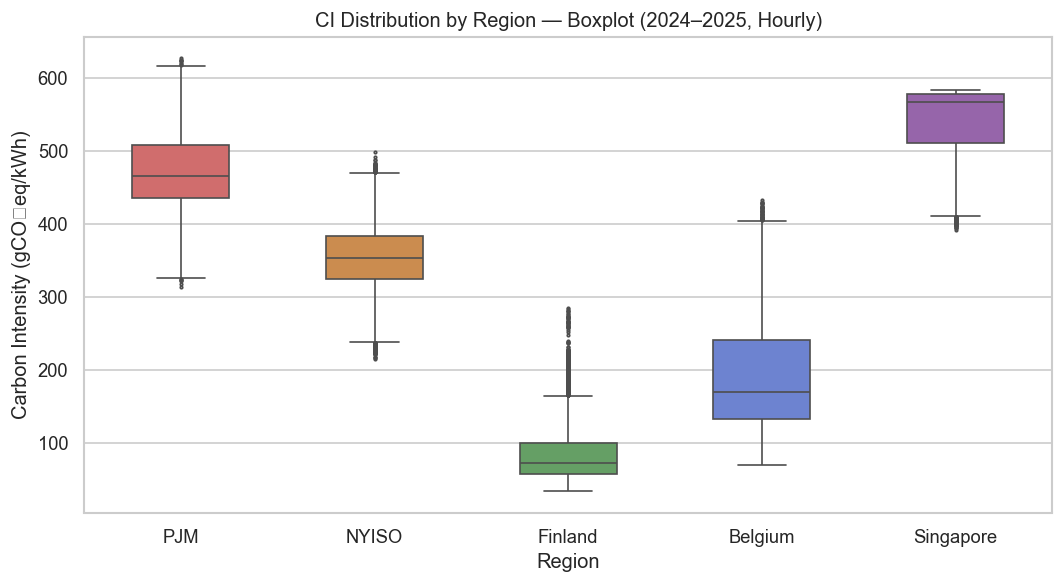

In [ ]:
all_df = pd.concat([df[["ci", "zone"]] for df in data.values()]).reset_index(drop=True)
zone_order = [ZONES[z]["label"] for z in ZONES]
palette = {ZONES[z]["label"]: ZONES[z]["color"] for z in ZONES}

# Figure 1: Boxplot
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=all_df, x="zone", y="ci", order=zone_order,
            palette=palette, width=0.5, fliersize=1.5, ax=ax)
ax.set_title("CI Distribution by Region — Boxplot (2024–2025, Hourly)")
ax.set_xlabel("Region")
ax.set_ylabel("Carbon Intensity (gCO₂eq/kWh)")
plt.tight_layout()
plt.savefig("../data/figures/eda_ci_boxplot.png", bbox_inches="tight")
plt.show()

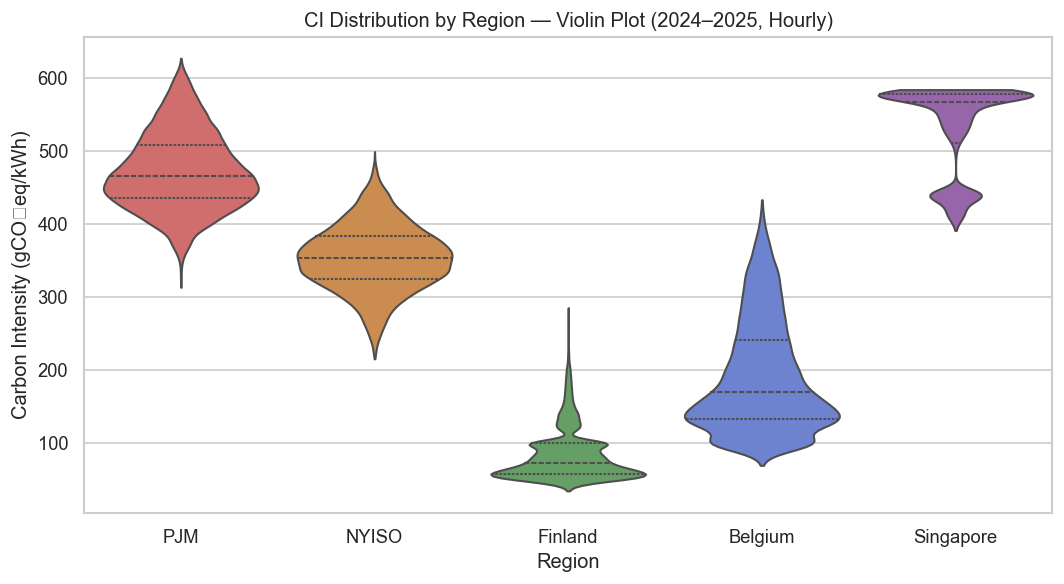

In [ ]:
# Figure 2: Violin plot
fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(data=all_df, x="zone", y="ci", order=zone_order,
               palette=palette, inner="quartile", cut=0, ax=ax)
ax.set_title("CI Distribution by Region — Violin Plot (2024–2025, Hourly)")
ax.set_xlabel("Region")
ax.set_ylabel("Carbon Intensity (gCO₂eq/kWh)")
plt.tight_layout()
plt.savefig("../data/figures/eda_ci_violin.png", bbox_inches="tight")
plt.show()

---
## 6. CI Time Series (Monthly Averages)

To visualize long-run trends, we plot monthly-averaged CI for each region. This reveals seasonal structure: Finland's CI drops sharply in summer (hydro + wind peak); PJM shows mild summer peaks from air-conditioning demand driving more gas generation. These seasonal patterns motivate the need for a full 2-year dataset rather than a single snapshot.

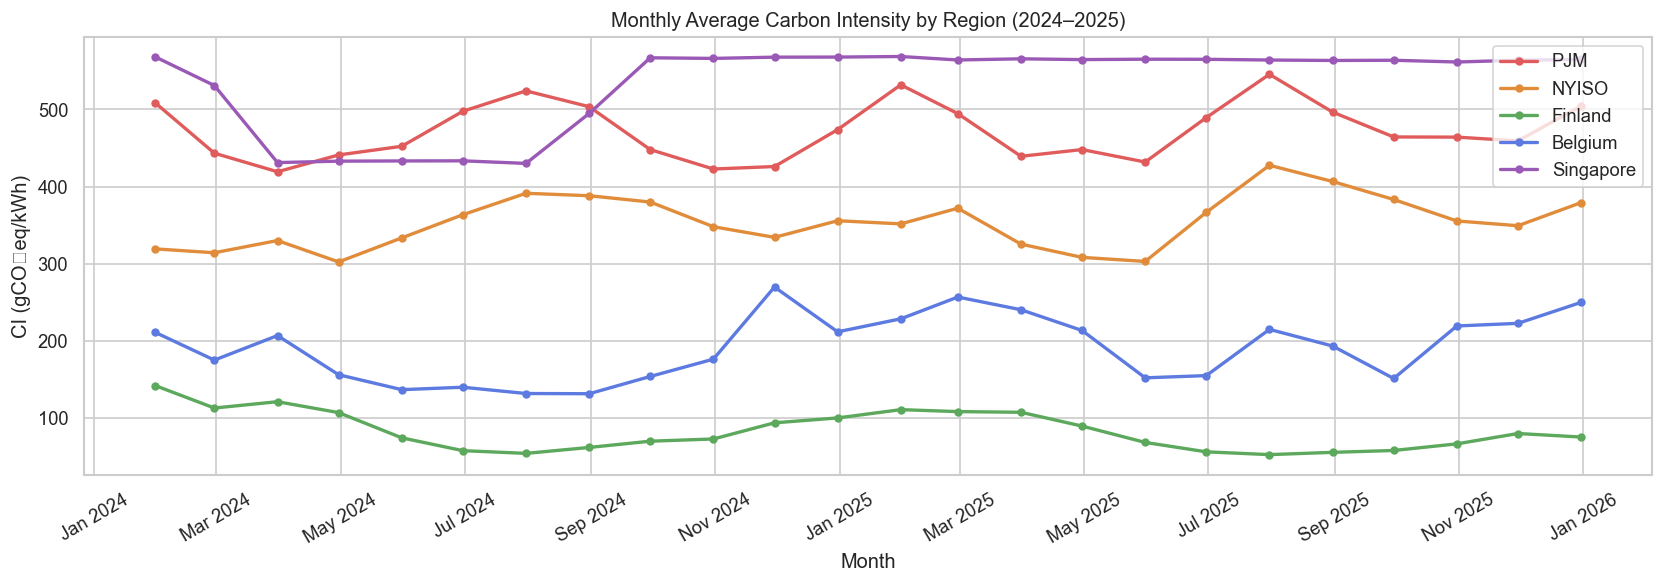

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

for zone, df in data.items():
    monthly = df["ci"].resample("ME").mean()
    ax.plot(monthly.index, monthly.values,
            label=ZONES[zone]["label"],
            color=ZONES[zone]["color"],
            linewidth=2, marker="o", markersize=4)

ax.set_title("Monthly Average Carbon Intensity by Region (2024–2025)")
ax.set_xlabel("Month")
ax.set_ylabel("CI (gCO₂eq/kWh)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("../data/figures/eda_ci_timeseries.png", bbox_inches="tight")
plt.show()

---
## 7. Diurnal Patterns — Average CI by Hour of Day

Intra-day CI patterns are the primary driver of **temporal shifting** decisions. A large gap between peak-hour and trough-hour CI creates opportunities to defer flexible AI workloads to cleaner windows. We compute the average CI for each hour of the day (UTC) across the full 2-year dataset.

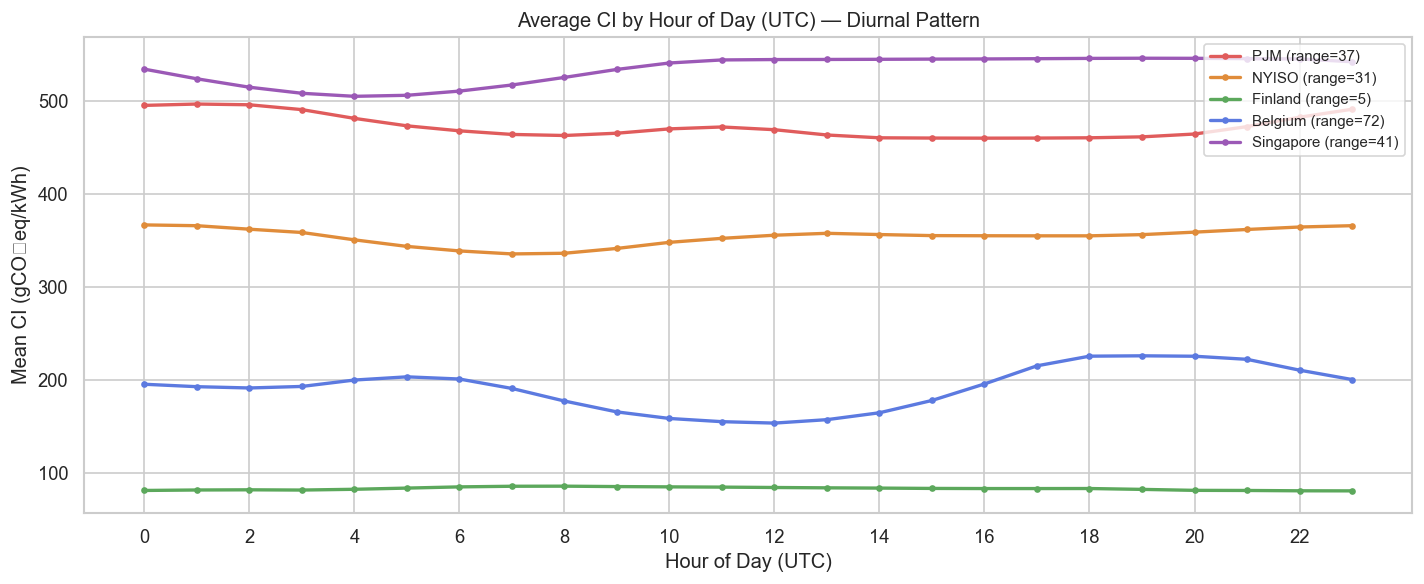


Diurnal range (max - min avg CI by hour):
  PJM         36.7 gCO₂/kWh
  NYISO       31.2 gCO₂/kWh
  Finland     5.1 gCO₂/kWh
  Belgium     72.4 gCO₂/kWh
  Singapore   41.0 gCO₂/kWh


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

for zone, df in data.items():
    hourly = df["ci"].groupby(df.index.hour).mean()
    diurnal_range = hourly.max() - hourly.min()
    ax.plot(hourly.index, hourly.values,
            label=f"{ZONES[zone]['label']} (range={diurnal_range:.0f})",
            color=ZONES[zone]["color"], linewidth=2, marker="o", markersize=3)

ax.set_title("Average CI by Hour of Day (UTC) — Diurnal Pattern")
ax.set_xlabel("Hour of Day (UTC)")
ax.set_ylabel("Mean CI (gCO₂eq/kWh)")
ax.set_xticks(range(0, 24, 2))
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("../data/figures/eda_diurnal.png", bbox_inches="tight")
plt.show()

print("\nDiurnal range (max - min avg CI by hour):")
for zone, df in data.items():
    hourly = df["ci"].groupby(df.index.hour).mean()
    print(f"  {ZONES[zone]['label']:10}  {hourly.max() - hourly.min():.1f} gCO₂/kWh")

---
## 8. Seasonal Patterns — Average CI by Month

Seasonal variation drives **long-horizon temporal shifting** and explains why Finland's CI distribution is right-skewed despite its very low annual mean. We compute mean CI per calendar month to expose these patterns.

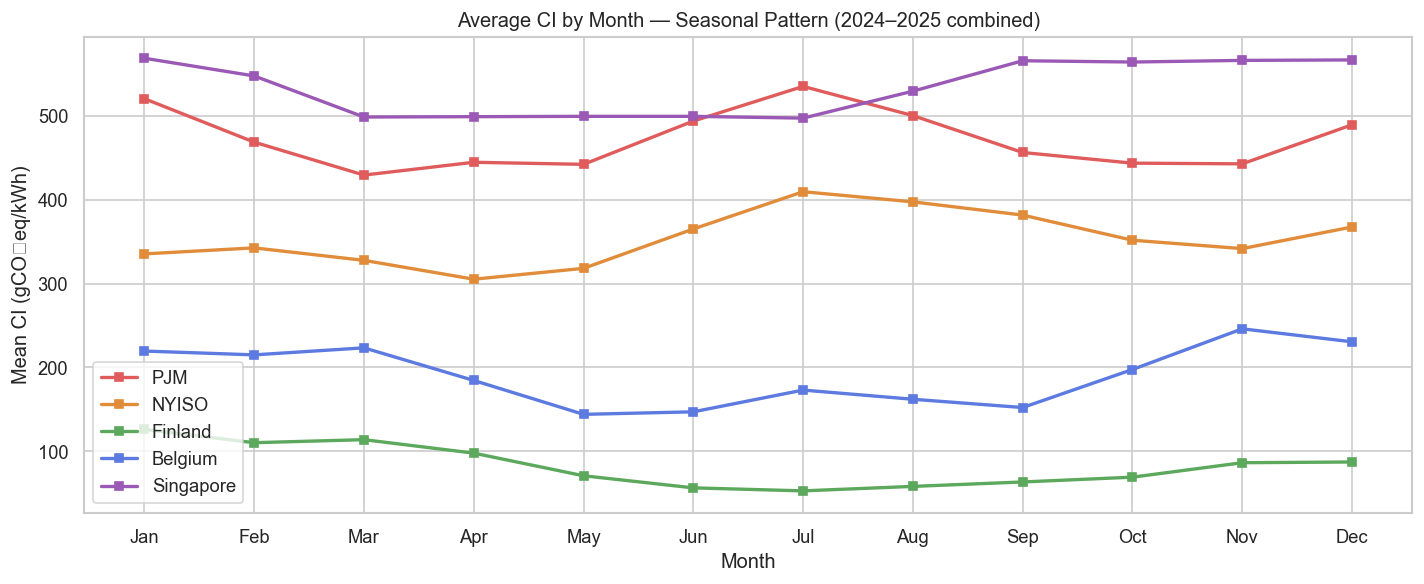

In [ ]:
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
fig, ax = plt.subplots(figsize=(12, 5))

for zone, df in data.items():
    monthly = df["ci"].groupby(df.index.month).mean()
    ax.plot(monthly.index, monthly.values,
            label=ZONES[zone]["label"],
            color=ZONES[zone]["color"], linewidth=2, marker="s", markersize=5)

ax.set_title("Average CI by Month — Seasonal Pattern (2024–2025 combined)")
ax.set_xlabel("Month")
ax.set_ylabel("Mean CI (gCO₂eq/kWh)")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(months)
ax.legend()
plt.tight_layout()
plt.savefig("../data/figures/eda_seasonal.png", bbox_inches="tight")
plt.show()

---
## 8.5 Cross-Region Correlation — Spatial Decorrelation and Routing Potential

The analyses so far characterize each region in isolation. The value of *spatial* routing, however, depends on the **relationship between regions**: routing flexible load from a dirty region to a clean one only helps if, when one region's CI is high, another's tends to be low. If all regions rose and fell together (high positive correlation), spatial routing would add nothing beyond temporal shifting within a region.

We therefore compute the Pearson correlation of hourly CI across all five regions over the aligned 2024–2025 series. Low or negative off-diagonal correlations indicate spatial decorrelation, which is the structural precondition for carbon savings from geographic load shifting (Riepin et al., 2024; Lindberg et al., 2022).

In [ ]:
# Cross-region hourly CI correlation over the aligned 2024-2025 series
ci_matrix = pd.DataFrame({ZONES[z]["label"]: data[z]["ci"] for z in ZONES}).dropna()
corr = ci_matrix.corr()

print("=== Cross-region hourly CI correlation (Pearson) ===")
print(corr.round(2).to_string())

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={"label": "Pearson correlation of hourly CI"}, ax=ax)
ax.set_title("Cross-Region Carbon-Intensity Correlation (2024-2025)")
plt.tight_layout()
plt.savefig("../data/figures/eda_ci_correlation.png", bbox_inches="tight")
plt.show()

# Single-number summary of spatial decorrelation
off_diag = corr.values[~np.eye(len(corr), dtype=bool)]
print(f"\nMean off-diagonal correlation: {off_diag.mean():.3f}")
print("Only the two US grids (PJM, NYISO) are strongly correlated (0.62); every other")
print("pair is near zero or negative (e.g. NYISO-Finland = -0.34). This decorrelation is")
print("the structural precondition for spatial routing to reduce carbon: when one region")
print("is dirty, another is usually clean and available to absorb the load.")

---
## 9. RF vs CFE Analysis — Nuclear Contribution by Region

We examine three complementary signals extracted from the ElectricityMaps `powerConsumptionBreakdown` field:

- **RF** (Renewable Fraction): wind + solar + hydro + geothermal + biomass share of total generation
- **Nuclear fraction**: nuclear share only
- **CFE fraction**: RF + nuclear — the signal used by Riepin et al. (2024) as the LP scheduling input

The gap between CFE and RF measures the nuclear contribution. Regions with large nuclear share (Belgium, Finland) will behave differently under a CFE-based objective vs an RF-based one. Singapore and PJM have near-zero nuclear, so CFE ≈ RF there.

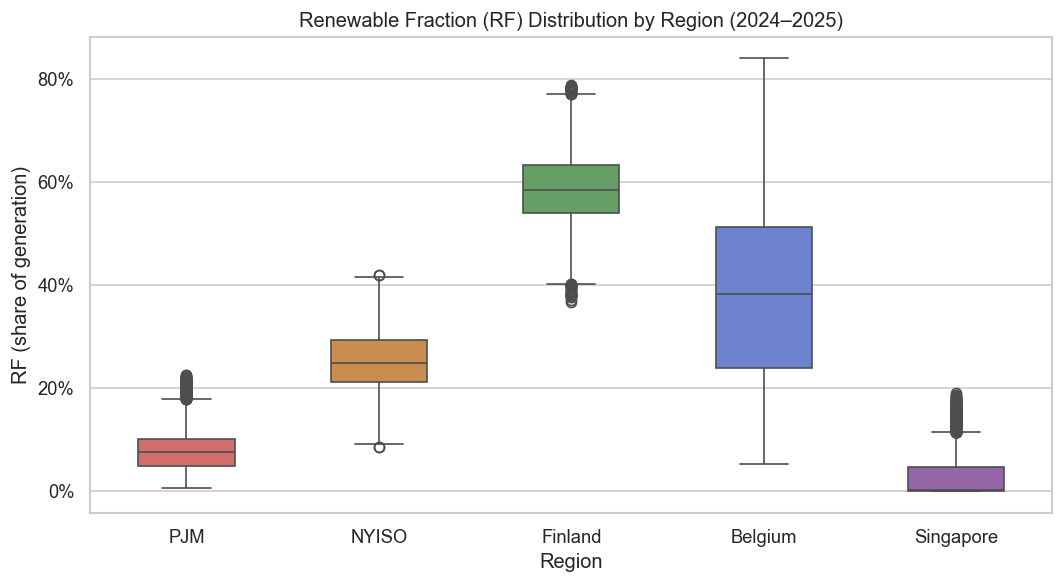

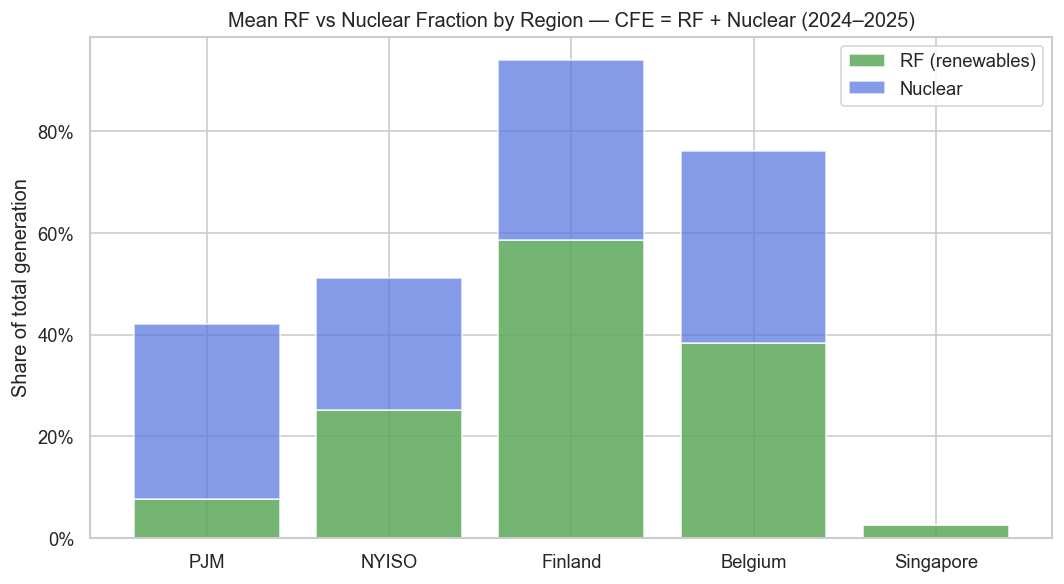

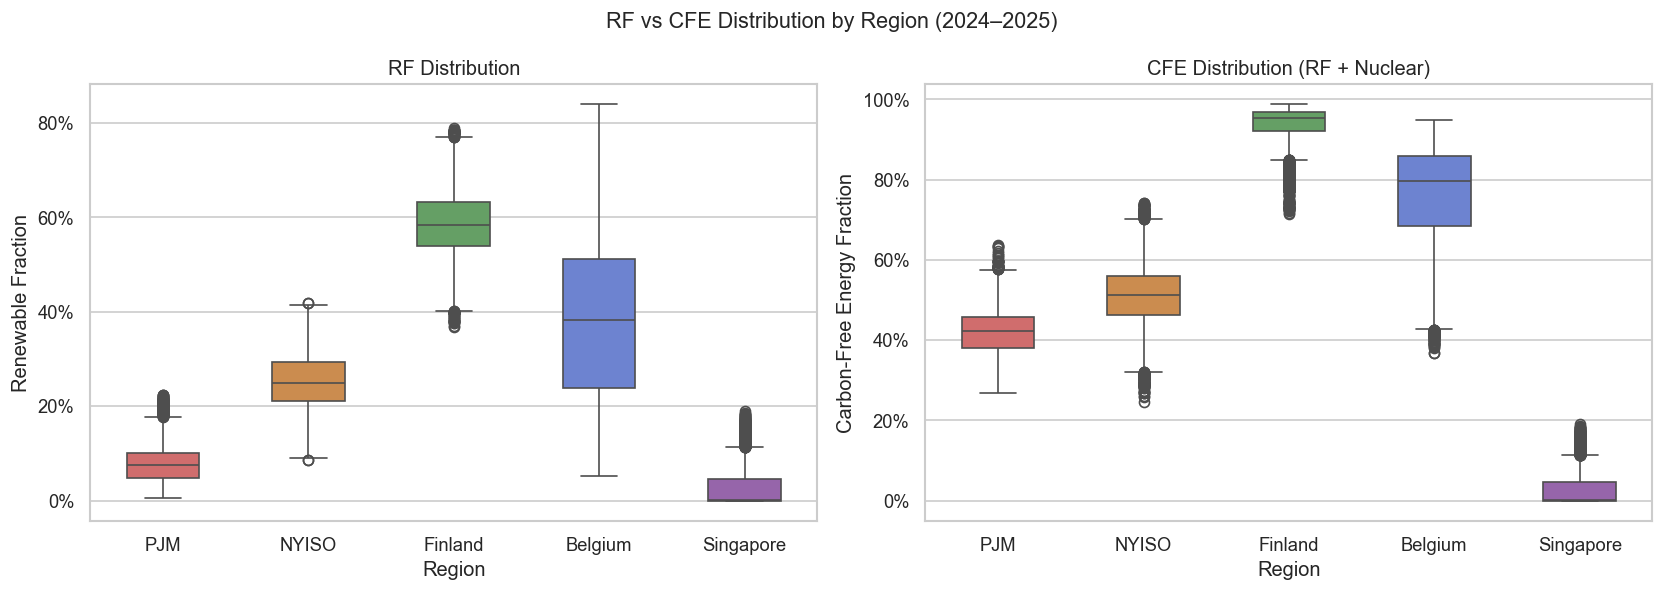

In [ ]:
if not HAS_CFE:
    print("CFE data not yet available. Showing RF only.\nRun src/fetch_cfe.py then re-run this cell.")

# Figure 1: RF distribution boxplot (always shown)
rf_all = pd.concat([df[["rf", "zone"]] for df in data.values()]).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=rf_all, x="zone", y="rf", order=zone_order,
            palette=palette, width=0.5, ax=ax)
ax.set_title("Renewable Fraction (RF) Distribution by Region (2024–2025)")
ax.set_xlabel("Region")
ax.set_ylabel("RF (share of generation)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.savefig("../data/figures/eda_rf_distribution.png", bbox_inches="tight")
plt.show()

if HAS_CFE:
    # Figure 2: RF vs CFE vs Nuclear stacked bar by region (mean values)
    nuclear_means = {ZONES[z]["label"]: data[z]["nuclear"].mean() for z in ZONES}
    rf_means      = {ZONES[z]["label"]: data[z]["rf"].mean()      for z in ZONES}
    labels = zone_order
    rf_vals  = [rf_means[l]      for l in labels]
    nuc_vals = [nuclear_means[l] for l in labels]

    fig, ax = plt.subplots(figsize=(9, 5))
    bars_rf  = ax.bar(labels, rf_vals,  label="RF (renewables)", color="#5ca85c", alpha=0.85)
    bars_nuc = ax.bar(labels, nuc_vals, bottom=rf_vals, label="Nuclear", color="#5c7ae0", alpha=0.75)
    ax.set_title("Mean RF vs Nuclear Fraction by Region — CFE = RF + Nuclear (2024–2025)")
    ax.set_ylabel("Share of total generation")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.legend()
    plt.tight_layout()
    plt.savefig("../data/figures/eda_rf_nuclear_stacked.png", bbox_inches="tight")
    plt.show()

    # Figure 3: CFE distribution boxplot
    cfe_all = pd.concat([df[["cfe", "zone"]] for df in data.values()]).reset_index(drop=True)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.boxplot(data=rf_all,  x="zone", y="rf",  order=zone_order, palette=palette, width=0.5, ax=axes[0])
    sns.boxplot(data=cfe_all, x="zone", y="cfe", order=zone_order, palette=palette, width=0.5, ax=axes[1])
    for ax, title, ylabel in zip(axes,
        ["RF Distribution", "CFE Distribution (RF + Nuclear)"],
        ["Renewable Fraction", "Carbon-Free Energy Fraction"]):
        ax.set_title(title)
        ax.set_xlabel("Region")
        ax.set_ylabel(ylabel)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    plt.suptitle("RF vs CFE Distribution by Region (2024–2025)", fontsize=13)
    plt.tight_layout()
    plt.savefig("../data/figures/eda_rf_cfe_boxplot.png", bbox_inches="tight")
    plt.show()

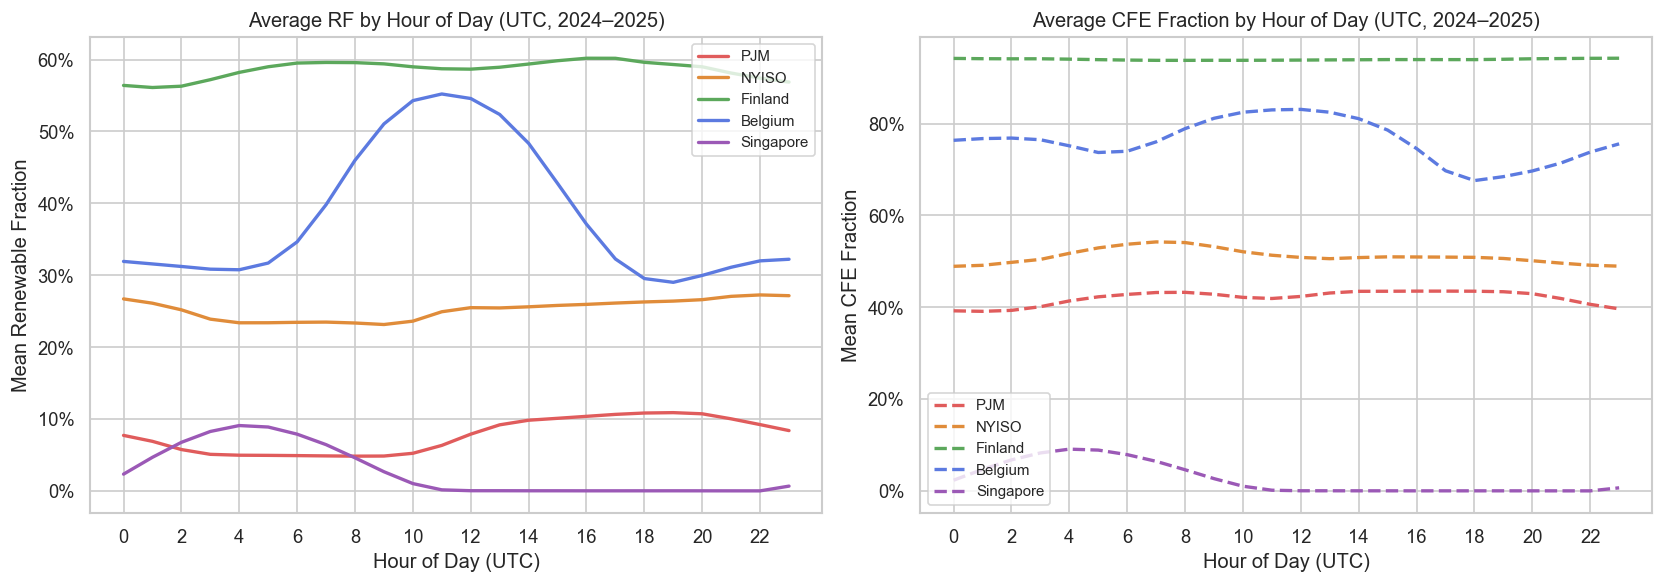

In [ ]:
# Diurnal patterns: RF and CFE by hour of day
fig, axes = plt.subplots(1, 2 if HAS_CFE else 1, figsize=(14 if HAS_CFE else 10, 5))
if not HAS_CFE:
    axes = [axes]

for zone, df in data.items():
    rf_hourly = df["rf"].groupby(df.index.hour).mean()
    axes[0].plot(rf_hourly.index, rf_hourly.values,
                 label=ZONES[zone]["label"], color=ZONES[zone]["color"], linewidth=2)

axes[0].set_title("Average RF by Hour of Day (UTC, 2024–2025)")
axes[0].set_xlabel("Hour of Day (UTC)")
axes[0].set_ylabel("Mean Renewable Fraction")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend(fontsize=9)

if HAS_CFE:
    for zone, df in data.items():
        cfe_hourly = df["cfe"].groupby(df.index.hour).mean()
        axes[1].plot(cfe_hourly.index, cfe_hourly.values,
                     label=ZONES[zone]["label"], color=ZONES[zone]["color"],
                     linewidth=2, linestyle="--")
    axes[1].set_title("Average CFE Fraction by Hour of Day (UTC, 2024–2025)")
    axes[1].set_xlabel("Hour of Day (UTC)")
    axes[1].set_ylabel("Mean CFE Fraction")
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    axes[1].set_xticks(range(0, 24, 2))
    axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("../data/figures/eda_rf_cfe_diurnal.png", bbox_inches="tight")
plt.show()

---
## 10. CI–CFE Relationship — Evaluating CFE as a Scheduling Signal

Riepin et al. (2024) use 24/7 CFE fraction as the LP objective signal in the closest prior work to this thesis. Before adopting CFE as a signal here, we need to verify empirically that it carries scheduling-relevant information beyond CI alone, and whether it correlates with CI more strongly than RF does.

The analysis mirrors Section 9 but targets CFE. We compare:
- CI vs RF correlation (already established)
- CI vs CFE correlation (new)
- OLS regression: CI ~ CFE, deriving the implied discount form
- Functional form comparison (additive vs multiplicative) for CFE

The region with the most expected difference is Belgium and Finland, where nuclear contributes substantially to CFE but not to RF.

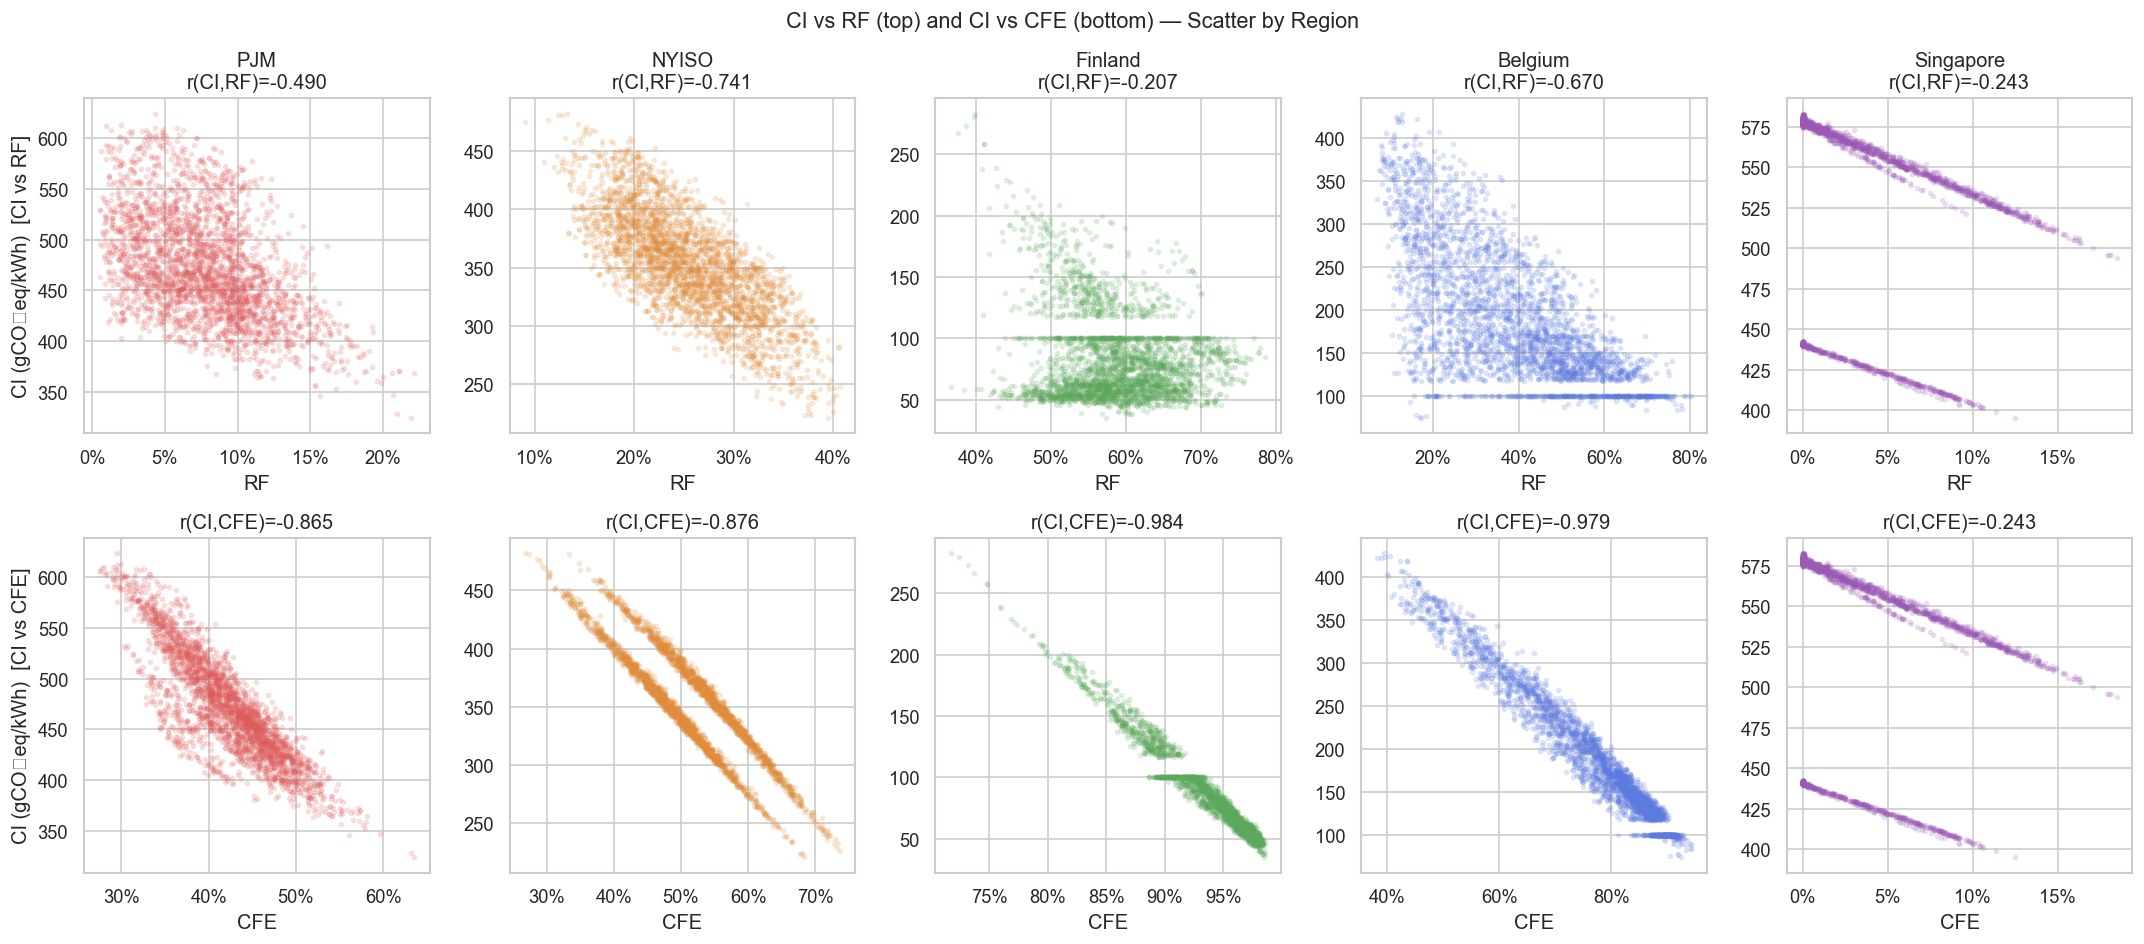


Pearson correlation comparison:
Region      r(CI,RF)   r(CI,CFE)  Stronger signal
PJM         -0.490     -0.865     CFE
NYISO       -0.741     -0.876     CFE
Finland     -0.207     -0.984     CFE
Belgium     -0.670     -0.979     CFE
Singapore   -0.243     -0.243     RF


In [ ]:
if not HAS_CFE:
    print("CFE data not yet available — showing CI vs RF only.")
    fig, axes = plt.subplots(1, len(ZONES), figsize=(18, 4), sharey=False)
    for ax, (zone, df) in zip(axes, data.items()):
        sample = df.sample(min(3000, len(df)), random_state=42)
        corr = df["ci"].corr(df["rf"])
        ax.scatter(sample["rf"], sample["ci"], alpha=0.15, s=8, color=ZONES[zone]["color"])
        ax.set_title(f"{ZONES[zone]['label']}\nr(CI,RF) = {corr:.3f}")
        ax.set_xlabel("Renewable Fraction")
        ax.set_ylabel("CI (gCO₂eq/kWh)" if ax == axes[0] else "")
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    plt.suptitle("CI vs RF Scatter by Region (sample n=3,000)", fontsize=13)
    plt.tight_layout()
    plt.savefig("../data/figures/eda_ci_rf_scatter.png", bbox_inches="tight")
    plt.show()
else:
    fig, axes = plt.subplots(2, len(ZONES), figsize=(18, 8), sharey=False)
    for col, (zone, df) in enumerate(data.items()):
        sample = df.sample(min(3000, len(df)), random_state=42)
        corr_rf  = df["ci"].corr(df["rf"])
        corr_cfe = df["ci"].corr(df["cfe"])

        axes[0, col].scatter(sample["rf"],  sample["ci"], alpha=0.15, s=6, color=ZONES[zone]["color"])
        axes[0, col].set_title(f"{ZONES[zone]['label']}\nr(CI,RF)={corr_rf:.3f}")
        axes[0, col].set_xlabel("RF")
        axes[0, col].xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

        axes[1, col].scatter(sample["cfe"], sample["ci"], alpha=0.15, s=6, color=ZONES[zone]["color"])
        axes[1, col].set_title(f"r(CI,CFE)={corr_cfe:.3f}")
        axes[1, col].set_xlabel("CFE")
        axes[1, col].xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

        if col == 0:
            axes[0, col].set_ylabel("CI (gCO₂eq/kWh)  [CI vs RF]")
            axes[1, col].set_ylabel("CI (gCO₂eq/kWh)  [CI vs CFE]")

    plt.suptitle("CI vs RF (top) and CI vs CFE (bottom) — Scatter by Region", fontsize=13)
    plt.tight_layout()
    plt.savefig("../data/figures/eda_ci_rf_cfe_scatter.png", bbox_inches="tight")
    plt.show()

    print("\nPearson correlation comparison:")
    print(f"{'Region':10}  r(CI,RF)   r(CI,CFE)  Stronger signal")
    for zone, df in data.items():
        r_rf  = df["ci"].corr(df["rf"])
        r_cfe = df["ci"].corr(df["cfe"])
        stronger = "CFE" if abs(r_cfe) > abs(r_rf) else "RF"
        print(f"{ZONES[zone]['label']:10}  {r_rf:+.3f}     {r_cfe:+.3f}     {stronger}")

---
### 10.1 OLS Regression: CI ~ RF and CI ~ CFE

We run OLS regression separately for RF and CFE against CI for each region. The comparison tells us:
- Which signal has a stronger linear relationship with CI (higher R²)
- Whether the functional form recommendation (additive vs multiplicative) differs between signals
- Whether a single shared α is feasible across regions for CFE, as it needs to be to keep the LP parsimonious

Both regressions follow: CI = β₀ + β₁·signal, where signal ∈ {RF, CFE}.

In [ ]:
from scipy import stats

def run_regression(data, signal_col):
    results = []
    params  = {}
    for zone, df in data.items():
        clean = df[[signal_col, "ci"]].dropna()
        x = clean[signal_col].values
        y = clean["ci"].values
        slope, intercept, r_value, p_value, _ = stats.linregress(x, y)
        ci_mean = y.mean()
        params[zone] = {"slope": slope, "intercept": intercept, "r": r_value}
        results.append({
            "Region":          ZONES[zone]["label"],
            "CI mean":         round(ci_mean, 1),
            "β₀":              round(intercept, 1),
            "β₁":              round(slope, 1),
            "β₁ / CI mean":   round(slope / ci_mean, 3),
            "α implied":       round(-slope / intercept, 3),
            "R²":              round(r_value**2, 3),
            "p-value":         f"{p_value:.2e}",
        })
    return pd.DataFrame(results).set_index("Region"), params

print("=== OLS: CI ~ RF ===")
reg_rf_df, reg_rf_params = run_regression(data, "rf")
print(reg_rf_df.to_string())

if HAS_CFE:
    print("\n=== OLS: CI ~ CFE ===")
    reg_cfe_df, reg_cfe_params = run_regression(data, "cfe")
    print(reg_cfe_df.to_string())

    print("\n=== R² comparison (higher = stronger linear signal) ===")
    print(f"{'Region':10}  R²(CI~RF)  R²(CI~CFE)  Better")
    for i, (zone, df) in enumerate(data.items()):
        r2_rf  = reg_rf_df.loc[ZONES[zone]["label"],  "R²"]
        r2_cfe = reg_cfe_df.loc[ZONES[zone]["label"], "R²"]
        better = "CFE" if r2_cfe > r2_rf else "RF "
        print(f"{ZONES[zone]['label']:10}  {r2_rf:.3f}      {r2_cfe:.3f}       {better}")
else:
    reg_cfe_params = {}
    print("\nCFE regression skipped — run src/fetch_cfe.py first.")

# Keep reg_rf_params as the primary reference for backward compatibility
reg_params = reg_rf_params

=== OLS: CI ~ RF ===
           CI mean     β₀     β₁  β₁ / CI mean  α implied     R²    p-value
Region                                                                     
PJM          472.7  525.3 -683.0        -1.445      1.300  0.240   0.00e+00
NYISO        353.7  501.0 -583.4        -1.649      1.164  0.550   0.00e+00
Finland       82.7  145.8 -107.5        -1.299      0.738  0.043  6.74e-169
Belgium      191.2  308.0 -304.5        -1.592      0.989  0.449   0.00e+00
Singapore    533.2  543.2 -377.3        -0.708      0.695  0.059  1.12e-234

=== OLS: CI ~ CFE ===
           CI mean     β₀     β₁  β₁ / CI mean  α implied     R²    p-value
Region                                                                     
PJM          472.7  817.7 -820.7        -1.736      1.004  0.748   0.00e+00
NYISO        353.7  616.3 -514.1        -1.454      0.834  0.768   0.00e+00
Finland       82.7  882.5 -851.2       -10.286      0.964  0.968   0.00e+00
Belgium      191.2  656.0 -610.6        -3.1

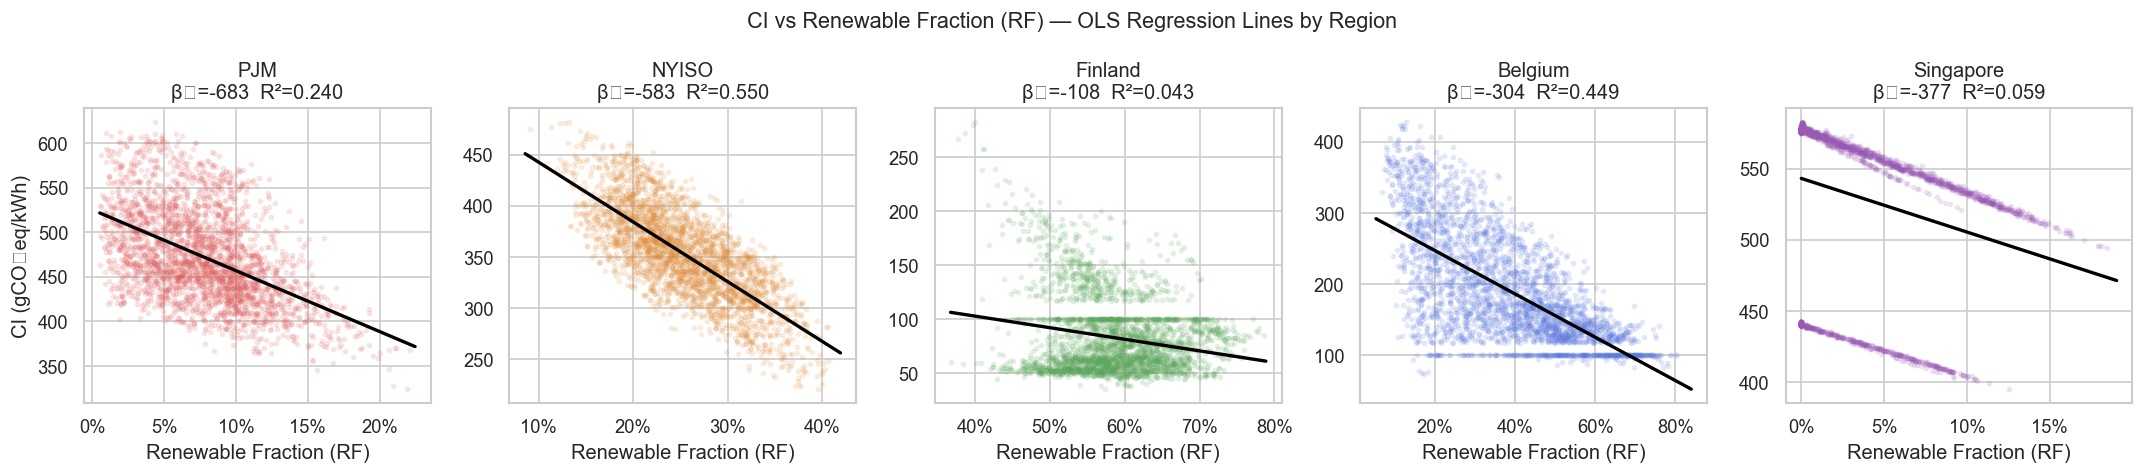

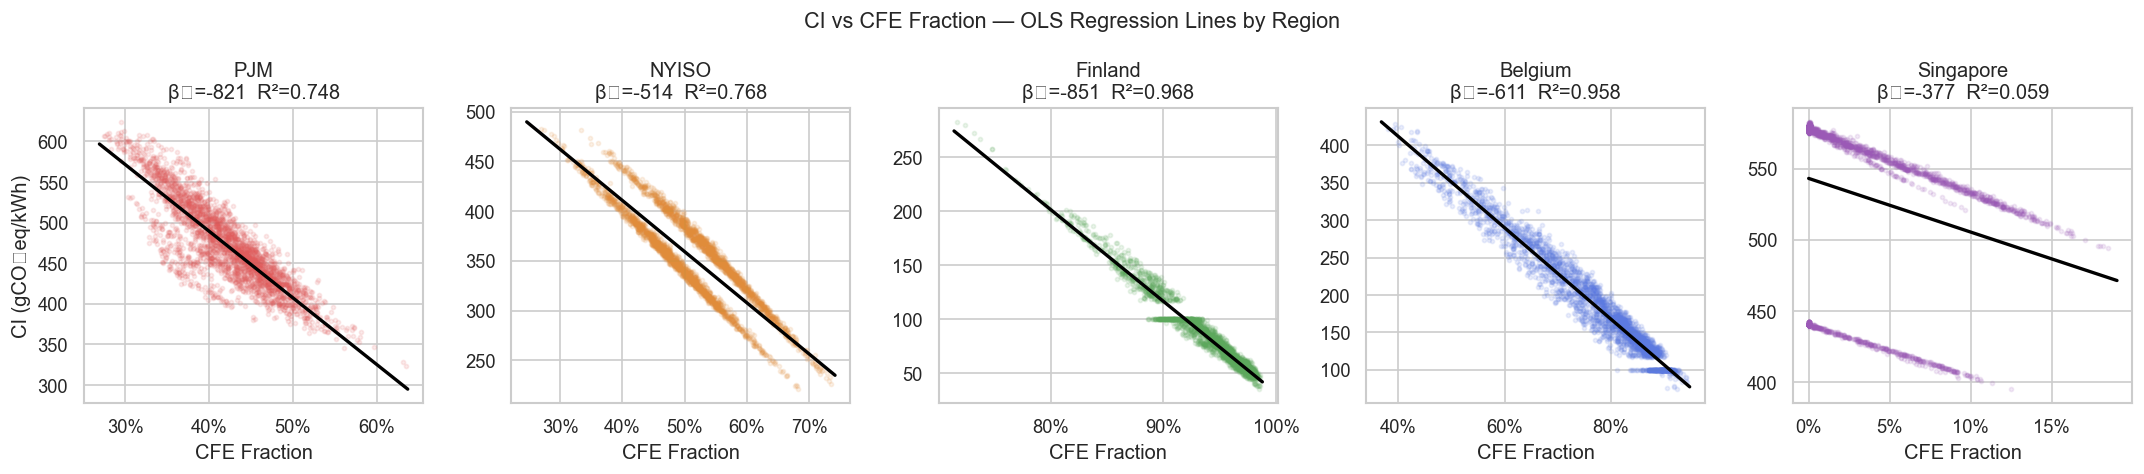

In [ ]:
def plot_regression_row(data, params, signal_col, signal_label, filename):
    fig, axes = plt.subplots(1, len(ZONES), figsize=(18, 4), sharey=False)
    for ax, (zone, df) in zip(axes, data.items()):
        sample = df.sample(min(3000, len(df)), random_state=42)
        p = params[zone]
        x_range = np.linspace(df[signal_col].min(), df[signal_col].max(), 100)
        ci_hat  = p["intercept"] + p["slope"] * x_range
        ax.scatter(sample[signal_col], sample["ci"], alpha=0.12, s=6, color=ZONES[zone]["color"])
        ax.plot(x_range, ci_hat, color="black", linewidth=2)
        ax.set_title(f"{ZONES[zone]['label']}\nβ₁={p['slope']:.0f}  R²={p['r']**2:.3f}")
        ax.set_xlabel(signal_label)
        ax.set_ylabel("CI (gCO₂eq/kWh)" if ax == axes[0] else "")
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    plt.suptitle(f"CI vs {signal_label} — OLS Regression Lines by Region", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"../data/figures/{filename}", bbox_inches="tight")
    plt.show()

plot_regression_row(data, reg_rf_params, "rf", "Renewable Fraction (RF)", "eda_ci_rf_regression.png")

if HAS_CFE:
    plot_regression_row(data, reg_cfe_params, "cfe", "CFE Fraction", "eda_ci_cfe_regression.png")

---
### 10.2 Functional Form: Additive vs Multiplicative (RF and CFE)

For each signal (RF and CFE), we test whether an additive or multiplicative discount better fits CI:
- **Additive**: effective cost = CI + β₁·signal (OLS directly gives this)
- **Multiplicative**: effective cost = CI·(1 − α·signal), α = −β₁/β₀

The test: compare MAE of each form per region. If additive consistently wins, the RF/CFE effect is a flat absolute reduction. If multiplicative wins, the effect scales with CI level. We also check CoV of the normalized slope β₁/CI_mean — lower CoV supports a single shared parameter across regions.

In [ ]:
def functional_form_comparison(data, params, signal_col, label):
    results = []
    for zone, df in data.items():
        p = params[zone]
        ci  = df["ci"].values
        sig = df[signal_col].values
        ci_mean = ci.mean()

        ci_hat_add = p["intercept"] + p["slope"] * sig
        mae_add    = np.mean(np.abs(ci - ci_hat_add))

        alpha      = -p["slope"] / p["intercept"]
        ci_hat_mul = ci_mean * (1 - alpha * sig)
        mae_mul    = np.mean(np.abs(ci - ci_hat_mul))

        results.append({
            "Region":     ZONES[zone]["label"],
            "β₁":         round(p["slope"], 1),
            "β₁/CI mean": round(p["slope"] / ci_mean, 3),
            "α (mult.)":  round(alpha, 3),
            "MAE add.":   round(mae_add, 2),
            "MAE mult.":  round(mae_mul, 2),
            "Better":     "Additive" if mae_add < mae_mul else "Multiplicative",
        })

    df_out = pd.DataFrame(results).set_index("Region")
    raw_slopes  = [r["β₁"]         for r in results]
    norm_slopes = [r["β₁/CI mean"] for r in results]
    cov_raw  = np.std(raw_slopes)  / abs(np.mean(raw_slopes))
    cov_norm = np.std(norm_slopes) / abs(np.mean(norm_slopes))
    print(f"\n--- {label} ---")
    print(df_out.to_string())
    print(f"\nCoV(β₁ raw) = {cov_raw:.3f}  |  CoV(β₁/CI mean) = {cov_norm:.3f}")
    print("→ Lower CoV of normalized slope = multiplicative form more consistent across regions")
    return df_out

print("=== Functional form: CI ~ RF ===")
form_rf = functional_form_comparison(data, reg_rf_params, "rf", "RF")

if HAS_CFE:
    print("\n=== Functional form: CI ~ CFE ===")
    form_cfe = functional_form_comparison(data, reg_cfe_params, "cfe", "CFE")

=== Functional form: CI ~ RF ===

--- RF ---
              β₁  β₁/CI mean  α (mult.)  MAE add.  MAE mult.          Better
Region                                                                      
PJM       -683.0      -1.447      1.300       NaN        NaN  Multiplicative
NYISO     -583.4      -1.649      1.164       NaN        NaN  Multiplicative
Finland   -107.5      -1.299      0.738     26.35      36.02        Additive
Belgium   -304.5      -1.592      0.989     44.26      75.87        Additive
Singapore -377.3      -0.708      0.695     49.60      54.66        Additive

CoV(β₁ raw) = 0.496  |  CoV(β₁/CI mean) = 0.252
→ Lower CoV of normalized slope = multiplicative form more consistent across regions

=== Functional form: CI ~ CFE ===

--- CFE ---
              β₁  β₁/CI mean  α (mult.)  MAE add.  MAE mult.          Better
Region                                                                      
PJM       -820.7      -1.738      1.004       NaN        NaN  Multiplicative
NYI

---
### 10.3 Implications for the LP Objective Signal

This section consolidates the regression evidence to decide which signal enters the LP objective.

**Decision logic:**

1. **Does the signal correlate significantly with CI?** All regions must show p ≪ 0.01. If a region fails this test, α is set to zero for that region and the model reverts to pure CI minimization.

2. **RF or CFE?** Compare R²(CI~RF) vs R²(CI~CFE) across all five regions. The signal with consistently higher R² carries more CI-relevant information and is preferred. If CFE is stronger (expected in Belgium and Finland due to nuclear), adopt CFE. If the difference is negligible, prefer RF for simplicity (no nuclear re-fetch required for future data).

3. **Additive or multiplicative?** The MAE comparison above determines the functional form. If additive wins across all regions, the LP effective cost term is CI + β₁·signal. If multiplicative wins, it is CI·(1 − α·signal).

4. **Single α or region-specific?** Check CoV of the normalized slope β₁/CI_mean. If CoV < 0.3, a single shared α is reasonable. If CoV ≥ 0.3, region-specific αᵣ values are warranted.

**Fallback:** For any region where |r| < 0.2, αᵣ = 0 regardless of the above — the signal adds no useful discriminating power there.

---
## 11. Key Findings & Implications for the Optimization Model

This section consolidates the EDA findings and maps them directly to modeling decisions.

In [ ]:
summary = []
for zone, df in data.items():
    cv = df["ci"].std() / df["ci"].mean()
    diurnal_range = df["ci"].groupby(df.index.hour).mean()
    r_rf  = df["ci"].corr(df["rf"])
    r_cfe = df["ci"].corr(df["cfe"]) if HAS_CFE else float("nan")

    row = {
        "Region":       ZONES[zone]["label"],
        "CI mean":      round(df["ci"].mean(), 1),
        "CV":           round(cv, 3),
        "Diurnal rng":  round(diurnal_range.max() - diurnal_range.min(), 1),
        "RF mean %":    round(df["rf"].mean() * 100, 1),
        "r(CI,RF)":     round(r_rf, 3),
        "CI var.":      "High" if cv > 0.15 else ("Medium" if cv > 0.08 else "Low"),
    }
    if HAS_CFE:
        row["Nuclear %"] = round(df["nuclear"].mean() * 100, 1)
        row["CFE %"]     = round(df["cfe"].mean() * 100, 1)
        row["r(CI,CFE)"] = round(r_cfe, 3)
        row["Better sig"] = "CFE" if abs(r_cfe) > abs(r_rf) else "RF"
    summary.append(row)

summary_df = pd.DataFrame(summary).set_index("Region")
print(summary_df.to_string())

print("""
Key takeaways:
1. Finland and Belgium show the highest CV — largest temporal shifting potential.
2. Singapore's narrow CI range confirms limited savings regardless of scheduling policy.
3. All regions: r(CI, RF) < 0, all statistically significant. RF and CFE both carry signal.
4. Nuclear fraction (CFE − RF) is material in Belgium and Finland — those regions will show
   the largest divergence between RF-based and CFE-based LP objectives.
5. The EDA regression (Section 10) determines which signal and functional form enters the LP.
""")

           CI mean     CV  Diurnal rng  RF mean %  r(CI,RF) CI var.  Nuclear %  CFE %  r(CI,CFE) Better sig
Region                                                                                                     
PJM          472.2  0.110         36.7        7.7    -0.490  Medium       34.3   42.0     -0.865        CFE
NYISO        353.7  0.125         31.2       25.2    -0.741  Medium       25.8   51.1     -0.876        CFE
Finland       82.7  0.420          5.1       58.6    -0.207    High       35.4   94.0     -0.984        CFE
Belgium      191.2  0.398         72.4       38.3    -0.670    High       37.8   76.1     -0.979        CFE
Singapore    533.2  0.112         41.0        2.7    -0.243  Medium        0.0    2.7     -0.243         RF

Key takeaways:
1. Finland and Belgium show the highest CV — largest temporal shifting potential.
2. Singapore's narrow CI range confirms limited savings regardless of scheduling policy.
3. All regions: r(CI, RF) < 0, all statistically signific